In [2]:
import yaml
from yaml.loader import FullLoader
from yaml.loader import SafeLoader
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [38]:
with open('flow_curves.yml') as f:
    meta_data = yaml.load(f, Loader=SafeLoader)

In [6]:
number_of_papers = len(meta_data['Papers'])
number_of_papers

10

In [39]:
#Check all of the curves load correctly
no_curves = 0
curve_list = []
for paper in meta_data['Papers']:
    no_curves += len(paper['Curves'])
    for curve in paper['Curves']:
#         print(curve['Curve_location'])
        flow_curve = np.loadtxt('Flow_curves/'+curve['Curve_location'], delimiter=",")
        curve_list.append(flow_curve)        

In [8]:
def sort_curve(curve):
    sorted_curve = np.zeros(np.shape(curve))
    ind = np.argsort(curve, axis=0)
    for i in range(len(curve)):
        sorted_curve[i,0]= curve[ind[i,0],0]
        sorted_curve[i,1]= curve[ind[i,0],1]
    return sorted_curve

In [23]:
def curve_filter(Temperature_C='any', 
                 Strain_rate='any', 
                 microstructure='any', 
                 heater='any',
                 sample_diameter='any',
                 sample_length='any'):
    no_curves = 0
    curve_list = []
    Paper_list =[]
    Author_list =[]
    for paper in meta_data['Papers']:
        for curve in paper['Curves']:
            temp_bool = curve['Temperature_C'] == Temperature_C or Temperature_C == 'any'
            strain_bool = curve['Strain_rate_s-1'] == Strain_rate or Strain_rate =='any'
            micro_bool = curve['microstructure_type'] == microstructure or microstructure == 'any'
            heat_bool = curve['In_situ_heating'] == heater or heater == 'any'
            diameter_bool = curve['sample_diameter_mm'] == sample_diameter or sample_diameter == 'any'
            length_bool = curve['sample_length_mm'] == sample_diameter or sample_diameter =='any'
            if temp_bool & strain_bool & micro_bool & diameter_bool & length_bool:
                flow_curve = np.loadtxt('Flow_curves/'+curve['Curve_location'], delimiter=",")
                flow_curve = sort_curve(flow_curve)
                curve_list.append(flow_curve)
                no_curves +=1
#                 print(paper['Paper'])
#                 print(paper['Authors'])
                Paper_list.append(paper['Paper'])
                Author_list.append(paper['Authors'])
    return curve_list, no_curves, Paper_list, Author_list
    

In [24]:
def curve_filter_pd(Temperature_C='any', 
                 Strain_rate='any', 
                 microstructure='any', 
                 heater='any',
                 sample_diameter='any',
                 sample_length='any'):
    no_curves = 0
    curve_list = []
    Paper_list =[]
    Author_list =[]
    for paper in meta_data['Papers']:
        for curve in paper['Curves']:
            temp_bool = curve['Temperature_C'] == Temperature_C or Temperature_C == 'any'
            strain_bool = curve['Strain_rate_s-1'] == Strain_rate or Strain_rate =='any'
            micro_bool = curve['microstructure_type'] == microstructure or microstructure == 'any'
            heat_bool = curve['In_situ_heating'] == heater or heater == 'any'
            diameter_bool = curve['sample_diameter_mm'] == sample_diameter or sample_diameter == 'any'
            length_bool = curve['sample_length_mm'] == sample_diameter or sample_diameter =='any'
            if temp_bool & strain_bool & micro_bool & diameter_bool & length_bool:
                flow_curve = pd.read_csv('Flow_curves/'+curve['Curve_location'])
                curve_list.append(flow_curve)
                no_curves +=1
#                 print(paper['Paper'])
#                 print(paper['Authors'])
                Paper_list.append(paper['Paper'])
                Author_list.append(paper['Authors'])
    return curve_list, no_curves, Paper_list, Author_list

In [25]:
def flow_curve_plotter(curve_list, fig_no, Authors, Temperature_C='any', Strain_rate='any', microstructure='any', heater='any'):
    for n,curve in enumerate(curve_list):
        plt.plot(curve[:,0], curve[:,1], label=Authors[n])
    Title = 'Flow curves of Ti64 with ' + microstructure +' at ' + str(Temperature_C) + 'C and ' + str(Strain_rate)+ 's-1 strain rate'
    plt.title(Title)
    plt.xlabel('strain')
    plt.ylabel('Stress/MPa')
    plt.legend(bbox_to_anchor=[1, 1])


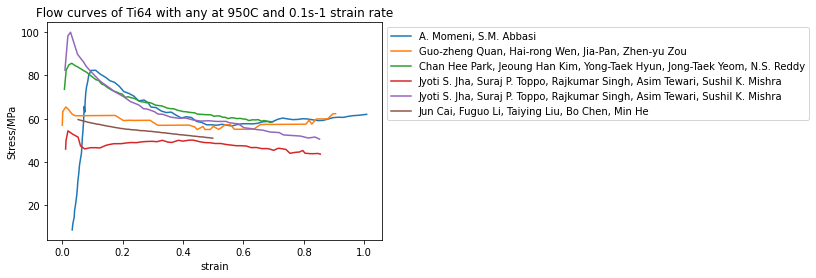

In [36]:
%matplotlib inline
fig_no = 1
Temperature_C=950
Strain_rate=0.1
microstructure='any'
heater = 'any'
sample_diameter ='any'
sample_length = 'any'
curve_list, no,Papers,Authors = curve_filter(Temperature_C, Strain_rate, microstructure,heater, sample_diameter, sample_length)
flow_curve_plotter(curve_list, fig_no, Authors,Temperature_C, Strain_rate, microstructure)

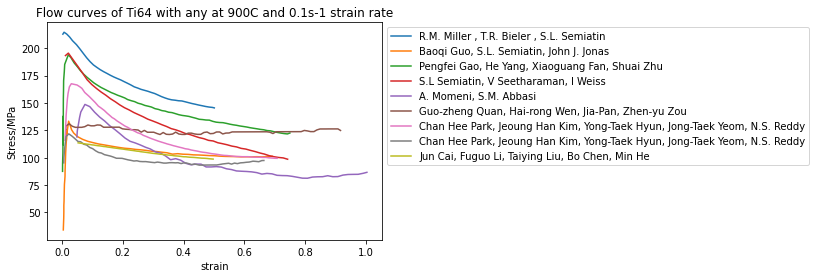

In [37]:
fig_no = 1
plt.clf()
Temperature_C=900
Strain_rate=0.1
microstructure='any'
heater = 'any'
sample_diameter ='any'
sample_length = 'any'
curve_list, no,Papers,Authors = curve_filter(Temperature_C, Strain_rate, microstructure,heater, sample_diameter, sample_length)
flow_curve_plotter(curve_list, fig_no, Authors,Temperature_C, Strain_rate, microstructure)